# Superstore Data Analysis using NumPy & Pandas

# Objective: To analyse the Sales, Profit Margin(Assume 20%),Time Series Analyisis

# import libraries 

In [6]:
import pandas as pd

In [7]:
import numpy as np

In [8]:
import matplotlib.pyplot as plt
from importlib import reload

# Load dataset

In [9]:
df=pd.read_csv(r"C:\Users\akars\Downloads\train.csv.zip")


In [10]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# basic Information gathering from dataset

In [ ]:
df.shape

In [70]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [71]:
df.index

RangeIndex(start=0, stop=9800, step=1)

In [72]:
df.values  #return data as Numpy ndarray

array([[1, 'CA-2017-152156', '08/11/2017', ..., 'Bookcases',
        'Bush Somerset Collection Bookcase', 261.96],
       [2, 'CA-2017-152156', '08/11/2017', ..., 'Chairs',
        'Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back',
        731.94],
       [3, 'CA-2017-138688', '12/06/2017', ..., 'Labels',
        'Self-Adhesive Address Labels for Typewriters by Universal',
        14.62],
       ...,
       [9798, 'CA-2016-128608', '12/01/2016', ..., 'Phones',
        'GE 30524EE4', 235.188],
       [9799, 'CA-2016-128608', '12/01/2016', ..., 'Phones',
        'Anker 24W Portable Micro USB Car Charger', 26.376],
       [9800, 'CA-2016-128608', '12/01/2016', ..., 'Accessories',
        'SanDisk Cruzer 4 GB USB Flash Drive', 10.384]],
      shape=(9800, 18), dtype=object)

In [73]:
df.size  #Total elements

176400

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [75]:
df.describe() #generates stastical summary of data

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


# Data Cleaning

In [76]:
df.drop_duplicates(inplace=True)
df.fillna(0, inplace=True)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [77]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

# 👉 “There are missing values in some columns which can affect analysis, so we need to handle them.”

In [78]:
df.fillna(0, inplace=True)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


# 👉 “Missing values are replaced with 0 to ensure no data loss during analysis.”

In [79]:
df["Profit"] = df["Sales"] * 0.2  #Assumed profit margin 20%

In [80]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Profit
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,52.3920
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,146.3880
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.9240
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,191.5155
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,4.4736


# 👉 “Since the dataset does not contain actual profit values, an estimated profit is calculated using an assumed margin of 20% for analysis purposes.”

# Profit margin Using NUmpy

In [81]:
df["Profit_Margin"] = np.where(df["Sales"] !=0,df["Profit"] / df["Sales"],0)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Profit,Profit_Margin
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,52.3920,0.2
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,146.3880,0.2
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.9240,0.2
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,191.5155,0.2
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,4.4736,0.2


# Sales Category Using Numpy

In [82]:
df["Sales_Category"] = np.where(df["Sales"] > 500, "High", "Low")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Profit,Profit_Margin,Sales_Category
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,52.3920,0.2,Low
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,146.3880,0.2,High
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.9240,0.2,Low
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,191.5155,0.2,High
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,4.4736,0.2,Low


# Data Analysis

# Sales By Category

In [11]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

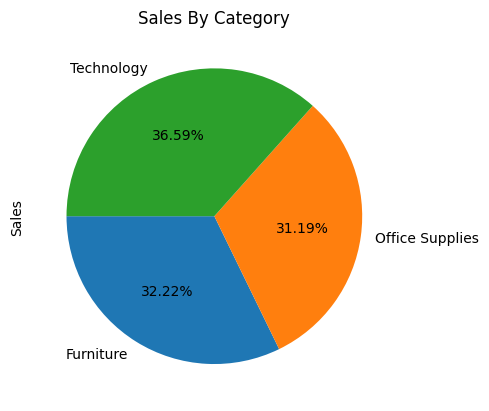

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
reload(plt)
df.groupby("Category")["Sales"].sum().plot(kind="pie" ,autopct='%1.2f%%',startangle=180)

plt.title("Sales By Category")
plt.show()

# Profit By Region

In [28]:
df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

Region
West       142043.93690
East       133903.74520
Central     98529.38264
South       77830.29180
Name: Profit, dtype: float64

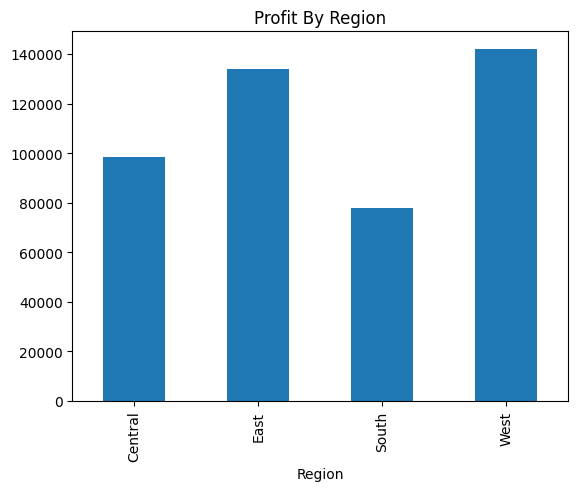

In [88]:
import matplotlib.pyplot as plt
from importlib import reload
reload(plt)
df.groupby("Region")["Profit"].sum().plot(kind="bar")
plt.title("Profit By Region")
plt.show()

# Top 10 Products

In [30]:
df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

# Bottom 10 Products

In [31]:
df.groupby("Product Name")["Sales"].sum().head(10)

Product Name
"While you Were Out" Message Book, One Form per Page                                          25.228
#10 Gummed Flap White Envelopes, 100/Box                                                      41.300
#10 Self-Seal White Envelopes                                                                108.682
#10 White Business Envelopes,4 1/8 x 9 1/2                                                   379.214
#10- 4 1/8" x 9 1/2" Recycled Envelopes                                                      286.672
#10- 4 1/8" x 9 1/2" Security-Tint Envelopes                                                 146.688
#10-4 1/8" x 9 1/2" Premium Diagonal Seam Envelopes                                          176.288
#6 3/4 Gummed Flap White Envelopes                                                            71.280
1.7 Cubic Foot Compact "Cube" Office Refrigerators                                          2706.080
1/4 Fold Party Design Invitations & White Envelopes, 24 8-1/2" X 11" Cards, 25

# Profit By Segment


In [32]:
df.groupby("Segment")["Profit"].sum()

Segment
Consumer       229612.10620
Corporate      137698.81496
Home Office     84996.43538
Name: Profit, dtype: float64

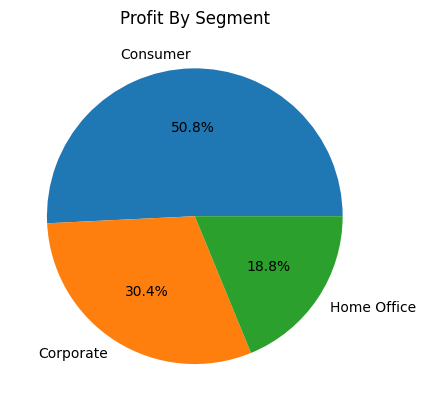

In [107]:
import matplotlib.pyplot as plt
from importlib import reload
reload(plt)
df.groupby("Segment")["Profit"].sum().plot(kind="pie",autopct='%1.1f%%')
plt.title("Profit By Segment")
plt.show()

# Sales By region


In [ ]:
df.groupby("Region")["Sales"].sum()

In [ ]:
import matplotlib.pyplot as plt
from importlib import reload
reload(plt)
df.groupby("Region")["Sales"].sum().plot(kind="bar")
plt.title("Sales By Region")
plt.show()

# Sales Trend

In [48]:
df.groupby("Order Date")["Sales"].sum()

Order Date
01/01/2018    1481.8280
01/02/2015     468.9000
01/02/2017     161.9700
01/03/2015    2203.1510
01/03/2016    1642.1744
                ...    
31/10/2017    3750.4990
31/10/2018     523.9280
31/12/2015    5253.2700
31/12/2016    1381.3440
31/12/2017     731.7680
Name: Sales, Length: 1230, dtype: float64

# South Analysis

In [50]:
train=df["Region"]=="South"
r=df[train]
r[["Row ID","Order ID","Ship Date","Customer ID","Region","Product Name"]]

,Row ID,Order ID,Ship Date,Customer ID,Region,Product Name
0,1,CA-2017-152156,11/11/2017,CG-12520,South,Bush Somerset Collection Bookcase
1,2,CA-2017-152156,11/11/2017,CG-12520,South,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
3,4,US-2016-108966,18/10/2016,SO-20335,South,Bretford CR4500 Series Slim Rectangular Table
4,5,US-2016-108966,18/10/2016,SO-20335,South,Eldon Fold 'N Roll Cart System
12,13,CA-2018-114412,20/04/2018,AA-10480,South,Xerox 1967
...,...,...,...,...,...,...
9770,9771,CA-2017-123533,30/11/2017,SC-20050,South,Tops Wirebound Message Log Books
9771,9772,CA-2017-123533,30/11/2017,SC-20050,South,Fellowes Advanced Computer Series Surge Protec...
9773,9774,CA-2017-160234,03/07/2017,PF-19225,South,Cisco IP Phone 7961G VoIP phone - Dark gray
9785,9786,CA-2016-155635,13/05/2016,ME-17725,South,Acco Flexible ACCOHIDE Square Ring Data Binder...


In [58]:
# 1. Calculate specific metrics for the South Region
south_stats = df[df['Region'] == 'South']
total_sales_south = south_stats['Sales'].sum()
total_profit_south = south_stats['Profit'].sum()
avg_profit_margin_south = (total_profit_south / total_sales_south) * 100

print(f"Total Sales in South: ${total_sales_south:,.2f}")
print(f"Total Profit in South: ${total_profit_south:,.2f}")
print(f"Average Profit Margin in South: {avg_profit_margin_south:.2f}%")

# 2. Comparison: Profit by Region to prove it's the lowest
region_comparison = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print("\nProfit Comparison by Region:")
print(region_comparison)

Total Sales in South: $389,151.46
Total Profit in South: $77,830.29
Average Profit Margin in South: 20.00%

Profit Comparison by Region:
Region
West       142043.93690
East       133903.74520
Central     98529.38264
South       77830.29180
Name: Profit, dtype: float64


# Identified the South region as a key area for expansion, as it currently contributes the lowest total volume to the bottom line.

# INSIGHTS

# Technology has higher sales among all category

# West Region generates maximum profit ,then east , central region, south has poor profits 

# Done the Analysis of TOP 10 and Bottom 10 Products

# Analyised the Profit by segment and get insights that consumer is maximum profit generator 

# West Region has maximum sales as studied the data and analyised

# Analyised the Sales trend to know sales on each date

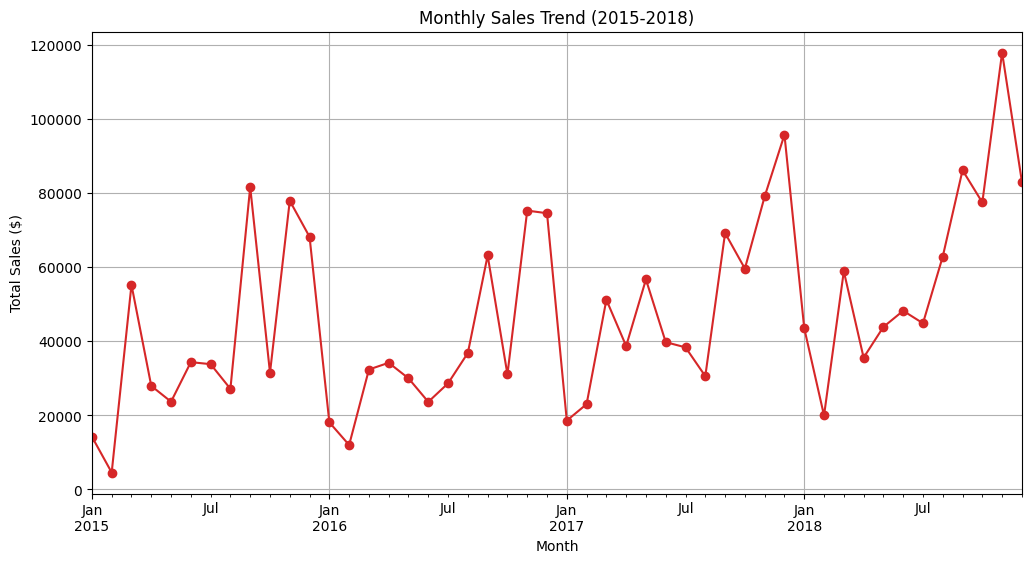

In [91]:
# 1. Convert Order Date to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# 2. Extract Year and Month for grouping
df['Month_Year'] = df['Order Date'].dt.to_period('M')

# 3. Calculate Monthly Sales
monthly_sales = df.groupby('Month_Year')['Sales'].sum()

# 4. Plot the Trend
plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line', marker='o', color='tab:red')
plt.title('Monthly Sales Trend (2015-2018)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True)
plt.show()